In [4]:
import pandas as pd

In [5]:
dados = pd.read_csv("Dados/flights.csv")

In [6]:
dados.head()

,flight_id,airline,aircraft_type,schengen,origin,arrival_time,departure_time,day,year,is_holiday,delay
0,26,MM,Airbus A320,non-schengen,TCY,8.885071,10.885071,0,2010,False,70.205981
1,10,YE,Airbus A320,non-schengen,TCY,8.939996,11.939996,0,2010,False,38.484609
2,3,BZ,Embraer E175,schengen,TZF,18.635384,22.635384,0,2010,False,2.388305
3,28,BZ,Airbus A330,non-schengen,EMM,15.967963,17.967963,0,2010,False,19.138491
4,15,BZ,Airbus A330,non-schengen,FJB,16.571894,19.571894,0,2010,False,15.016271


In [7]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71175 entries, 0 to 71174
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   flight_id       71175 non-null  int64  
 1   airline         71175 non-null  object 
 2   aircraft_type   71175 non-null  object 
 3   schengen        71175 non-null  object 
 4   origin          71175 non-null  object 
 5   arrival_time    71175 non-null  float64
 6   departure_time  71175 non-null  float64
 7   day             71175 non-null  int64  
 8   year            71175 non-null  int64  
 9   is_holiday      71175 non-null  bool   
 10  delay           71175 non-null  float64
dtypes: bool(1), float64(3), int64(3), object(4)
memory usage: 5.5+ MB


In [8]:
dados.shape

(71175, 11)

In [9]:
dados.describe()

,flight_id,arrival_time,departure_time,day,year,delay
count,71175.000000,71175.000000,71175.000000,71175.000000,71175.000000,71175.000000
mean,15.465135,13.283159,16.480222,182.000000,2016.000000,12.548378
std,8.649646,4.023380,4.143705,105.366769,3.741684,23.125349
min,1.000000,7.065594,10.065594,0.000000,2010.000000,-41.028033
25%,8.000000,8.939996,12.668655,91.000000,2013.000000,-4.412876
50%,15.000000,14.258911,16.376052,182.000000,2016.000000,9.740454
75%,23.000000,16.909690,20.041281,273.000000,2019.000000,27.650853
max,30.000000,19.341235,23.341235,364.000000,2022.000000,125.632352


In [10]:
dados.describe(include="O")

,airline,aircraft_type,schengen,origin
count,71175,71175,71175,71175
unique,3,6,2,10
top,BZ,Airbus A320,schengen,TZF
freq,47598,30778,42569,14162


### Visualização Gráfica de dados

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
average_delay = dados.groupby('airline')['delay'].mean().reset_index()
average_delay

,airline,delay
0,BZ,3.077595
1,MM,40.498007
2,YE,25.772248


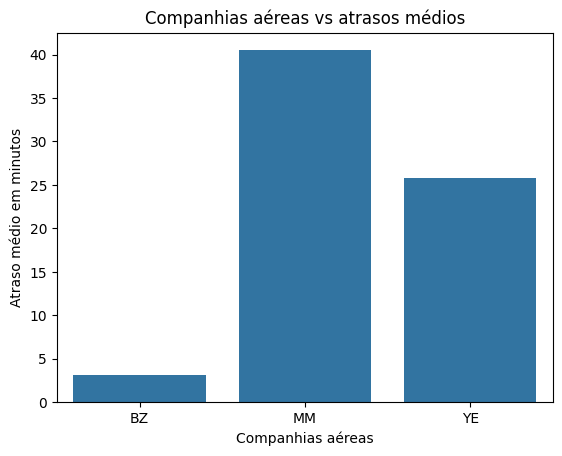

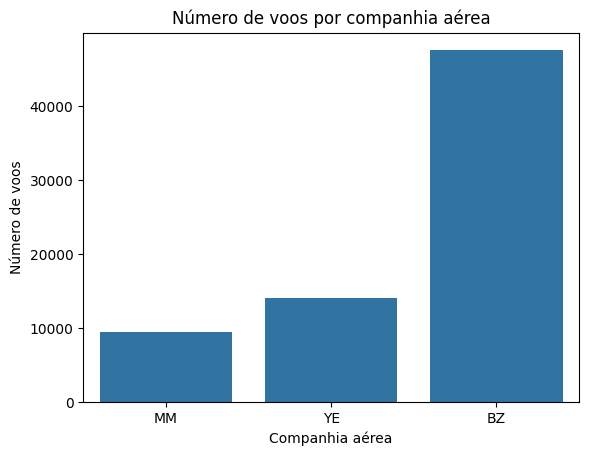

In [13]:
average_delay = dados.groupby('airline')['delay'].mean().reset_index()
sns.barplot(x='airline', y='delay', data=average_delay)
plt.title('Companhias aéreas vs atrasos médios')
plt.xlabel('Companhias aéreas')
plt.ylabel('Atraso médio em minutos')
plt.show()

sns.countplot(data=dados, x='airline')
plt.title('Número de voos por companhia aérea')
plt.xlabel('Companhia aérea')
plt.ylabel('Número de voos')
plt.show()


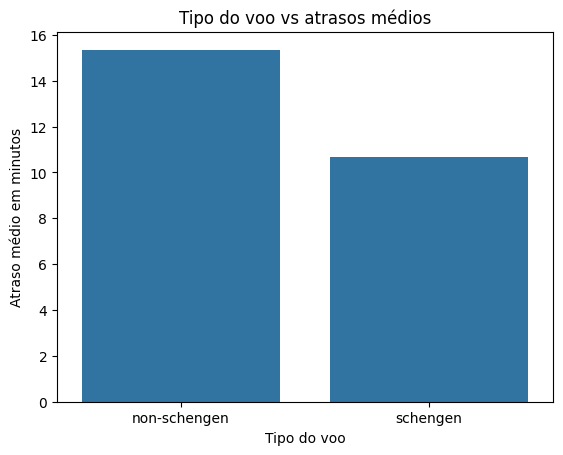

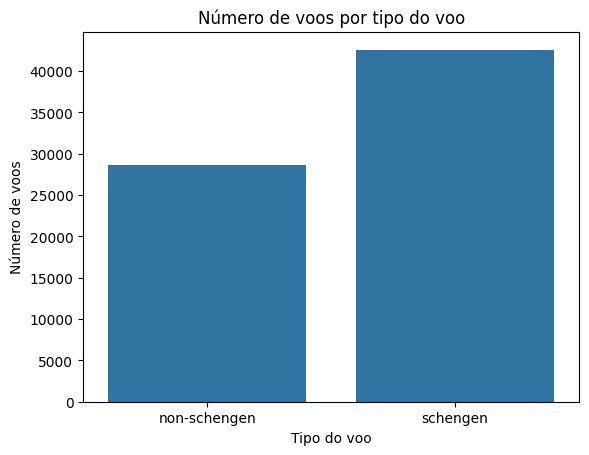

In [14]:
average_delay = dados.groupby('schengen')['delay'].mean().reset_index()
sns.barplot(x='schengen', y='delay', data=average_delay)
plt.title('Tipo do voo vs atrasos médios')
plt.xlabel('Tipo do voo')
plt.ylabel('Atraso médio em minutos')
plt.show()

sns.countplot(data=dados, x='schengen')
plt.title('Número de voos por tipo do voo')
plt.xlabel('Tipo do voo')
plt.ylabel('Número de voos')
plt.show()

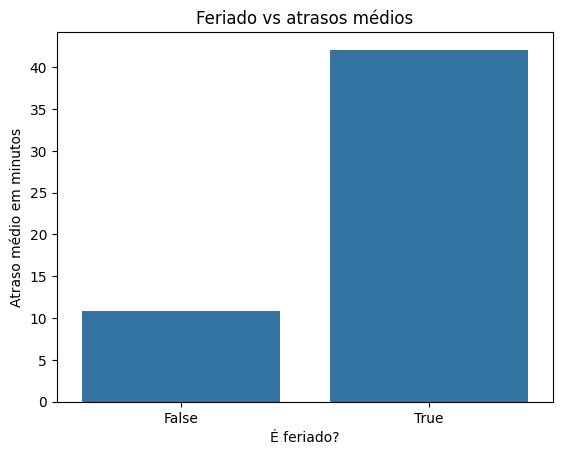

In [15]:
average_delay = dados.groupby('is_holiday')['delay'].mean().reset_index()
sns.barplot(x='is_holiday', y='delay', data=average_delay)
plt.title('Feriado vs atrasos médios')
plt.xlabel('É feriado?')
plt.ylabel('Atraso médio em minutos')
plt.show()


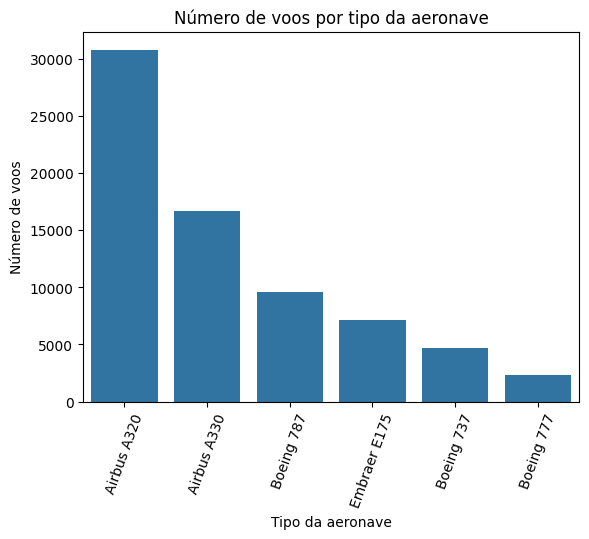

In [16]:
order = dados['aircraft_type'].value_counts().index
sns.countplot(data=dados, x='aircraft_type', order = order)
plt.title('Número de voos por tipo da aeronave')
plt.xticks(rotation=70)
plt.xlabel('Tipo da aeronave')
plt.ylabel('Número de voos')
plt.show()


### Analizando a distribuição dos dados

In [17]:
import numpy as np

def calcular_largura_bin(df, coluna):
    Q75, Q25 = np.percentile(df[coluna], [75 ,25])
    IQR = Q75 - Q25
    largura_bin = 2 * IQR * np.power(len(df[coluna]), -1/3)
    return largura_bin


<Axes: xlabel='arrival_time', ylabel='Count'>

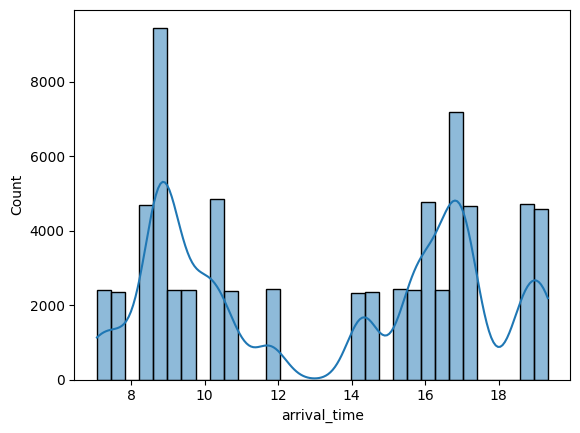

In [18]:
largura = calcular_largura_bin(dados, "arrival_time")
sns.histplot(data=dados, x="arrival_time", kde=True, binwidth=largura)

<Axes: xlabel='departure_time', ylabel='Count'>

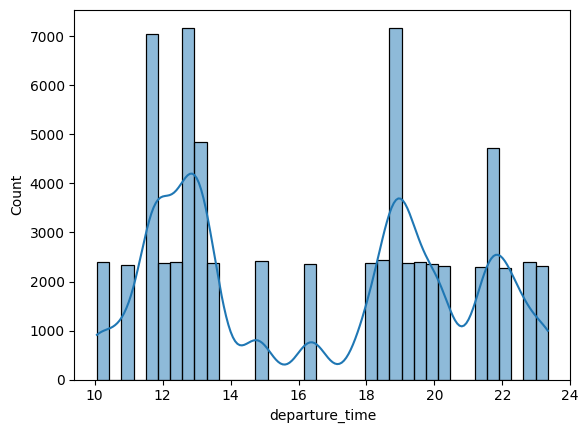

In [19]:
largura = calcular_largura_bin(dados, "departure_time")
sns.histplot(data=dados, x="departure_time", kde=True, binwidth=largura)

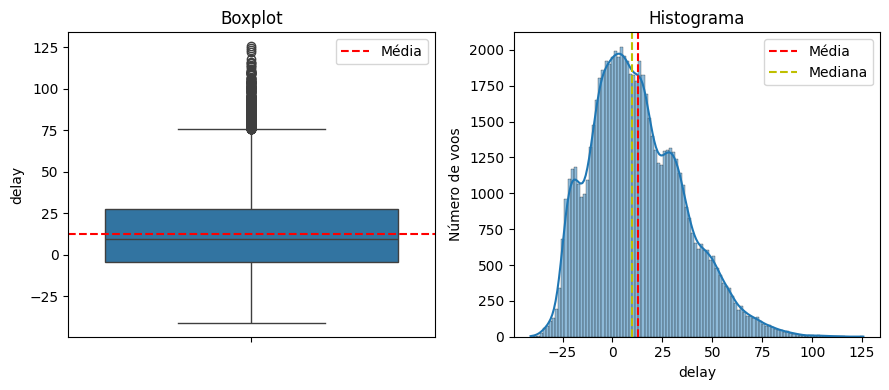

In [20]:
mean_delay = dados['delay'].mean()
median_delay = dados['delay'].median()

fig, axes = plt.subplots(1, 2, figsize=(9, 4))

sns.boxplot(data=dados, y='delay', ax=axes[0])
axes[0].set_title('Boxplot')

axes[0].axhline(y=mean_delay, color='r', linestyle='--', label='Média')
axes[0].legend()

largura_bin_delay = calcular_largura_bin(dados, 'delay')
sns.histplot(data=dados, x='delay', ax=axes[1], kde=True, binwidth=largura_bin_delay)
plt.ylabel('Número de voos')
plt.grid(False)
axes[1].set_title('Histograma')

axes[1].axvline(x=mean_delay, color='r', linestyle='--', label='Média')
axes[1].axvline(x=median_delay, color='y', linestyle='--', label='Mediana')
axes[1].legend()

plt.tight_layout()
plt.show()


### Aula 2 - Feature engineering

In [21]:
dados["date"] = pd.to_datetime(dados.year.astype(str) + "-" + (dados.day +1 ).astype(str), format="%Y-%j")

In [22]:
dados["is_weekend"] = dados.date.dt.weekday.isin([5, 6])

In [23]:
dados["day_name"] = dados.date.dt.day_name()

### Feature Encoding

In [24]:
dados.nunique()

flight_id            30
airline               3
aircraft_type         6
schengen              2
origin               10
arrival_time         30
departure_time       30
day                 365
year                 13
is_holiday            2
delay             71175
date               4745
is_weekend            2
day_name              7
dtype: int64

In [25]:
dados.schengen.unique()

array(['non-schengen', 'schengen'], dtype=object)

In [26]:
dados.is_holiday.unique()

array([False,  True])

In [27]:
dados.schengen = dados.schengen.replace({"non-schengen": 0, "schengen": 1})
dados.is_holiday = dados.is_holiday.replace({False: 0, True:1})
dados.is_holiday = dados.is_holiday.replace({False: 0, True:1})


C:\Users\Agostinho Pomba\AppData\Local\Temp\ipykernel_21232\2175387036.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dados.schengen = dados.schengen.replace({"non-schengen": 0, "schengen": 1})
C:\Users\Agostinho Pomba\AppData\Local\Temp\ipykernel_21232\2175387036.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dados.is_holiday = dados.is_holiday.replace({False: 0, True:1})


In [28]:
variaveis_categoricas = ['airline', 'aircraft_type', 'origin', 'day_name']


In [29]:
df_encoded = pd.get_dummies(data=dados, columns=variaveis_categoricas, dtype=int)
df_encoded.head()

,flight_id,schengen,arrival_time,departure_time,day,year,is_holiday,delay,date,is_weekend,...,origin_TCY,origin_TZF,origin_ZQO,day_name_Friday,day_name_Monday,day_name_Saturday,day_name_Sunday,day_name_Thursday,day_name_Tuesday,day_name_Wednesday
0,26,0,8.885071,10.885071,0,2010,0,70.205981,2010-01-01,False,...,1,0,0,1,0,0,0,0,0,0
1,10,0,8.939996,11.939996,0,2010,0,38.484609,2010-01-01,False,...,1,0,0,1,0,0,0,0,0,0
2,3,1,18.635384,22.635384,0,2010,0,2.388305,2010-01-01,False,...,0,1,0,1,0,0,0,0,0,0
3,28,0,15.967963,17.967963,0,2010,0,19.138491,2010-01-01,False,...,0,0,0,1,0,0,0,0,0,0
4,15,0,16.571894,19.571894,0,2010,0,15.016271,2010-01-01,False,...,0,0,0,1,0,0,0,0,0,0


### Limpar os dados

In [30]:
df_encoded[['arrival_time', 'departure_time']].corr()

,arrival_time,departure_time
arrival_time,1.000000,0.973797
departure_time,0.973797,1.000000


In [31]:
df_clean = df_encoded.drop(["departure_time", "flight_id", "day", "year", "date"], axis=1)

In [32]:
df_clean.head()

,schengen,arrival_time,is_holiday,delay,is_weekend,airline_BZ,airline_MM,airline_YE,aircraft_type_Airbus A320,aircraft_type_Airbus A330,...,origin_TCY,origin_TZF,origin_ZQO,day_name_Friday,day_name_Monday,day_name_Saturday,day_name_Sunday,day_name_Thursday,day_name_Tuesday,day_name_Wednesday
0,0,8.885071,0,70.205981,False,0,1,0,1,0,...,1,0,0,1,0,0,0,0,0,0
1,0,8.939996,0,38.484609,False,0,0,1,1,0,...,1,0,0,1,0,0,0,0,0,0
2,1,18.635384,0,2.388305,False,1,0,0,0,0,...,0,1,0,1,0,0,0,0,0,0
3,0,15.967963,0,19.138491,False,1,0,0,0,1,...,0,0,0,1,0,0,0,0,0,0
4,0,16.571894,0,15.016271,False,1,0,0,0,1,...,0,0,0,1,0,0,0,0,0,0


### Aula 3 - Seleção e Validação do Modelo

#### Treinamento DummyRegressor

In [33]:
X = df_clean.drop(columns="delay", axis=1)
y  = df_clean.delay

In [34]:
from sklearn.model_selection import train_test_split

In [35]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [36]:
from sklearn.dummy import DummyRegressor

model_dummy = DummyRegressor()
model_dummy.fit(X_train, y_train)

,strategy,'mean'
,constant,None
,quantile,None


In [37]:
y_pred = model_dummy.predict(X_test)

In [38]:
y_pred

array([12.52857512, 12.52857512, 12.52857512, ..., 12.52857512,
       12.52857512, 12.52857512], shape=(17794,))

In [39]:
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

def calcular_metricas_regressao(y_test, y_pred):

    rmse = root_mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    metricas = {
        'Raiz do Erro Quadrático Médio': round(rmse, 4),
        'Erro Absoluto Médio': round(mae, 4),
        'R2 Score': round(r2, 4)
    }
    return metricas


In [40]:
calcular_metricas_regressao(y_test, y_pred)

{'Raiz do Erro Quadrático Médio': 23.2241,
 'Erro Absoluto Médio': 18.6127,
 'R2 Score': -0.0}

In [41]:
from sklearn.ensemble import RandomForestRegressor

modelo_random = RandomForestRegressor(max_depth=5)
modelo_random.fit(X, y)
y_predict_rf = modelo_random.predict(X_test)

In [42]:
calcular_metricas_regressao(y_test, y_predict_rf)

{'Raiz do Erro Quadrático Médio': 13.7139,
 'Erro Absoluto Médio': 10.9949,
 'R2 Score': 0.6513}

In [ ]:
from yellowbrick.regressor import prediction_error

visualizer = prediction_error(modelo_random, X_train, y_train, X_test, y_test)


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


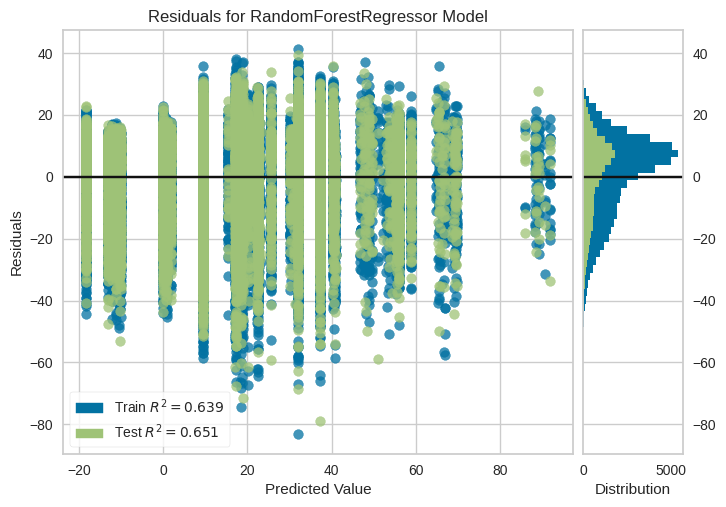

In [ ]:
from yellowbrick.regressor import residuals_plot

viz = residuals_plot(modelo_random, X_train, y_train, X_test, y_test)


In [ ]:
from sklearn.model_selection import KFold, cross_validate

scoring = {
    'mae': 'neg_mean_absolute_error',
    'rmse': 'neg_root_mean_squared_error',
    'r2': 'r2'
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

cv_results = cross_validate(modelo_random, X_train, y_train, cv=cv, scoring=scoring)
cv_results

{'fit_time': array([4.63959098, 3.24582839, 3.26057839, 3.98452449, 3.58091164]),
 'score_time': array([0.0651288 , 0.06564975, 0.06103301, 0.08440828, 0.0633812 ]),
 'test_mae': array([-11.07522128, -11.30303981, -11.05943695, -11.14411933,
        -11.17485957]),
 'test_rmse': array([-13.7675436 , -14.04889742, -13.79478923, -13.87666873,
        -13.93046346]),
 'test_r2': array([0.64675279, 0.62433139, 0.64528271, 0.64091127, 0.63476928])}

In [ ]:
for metric in scoring.keys():
    scores = cv_results[f'test_{metric}']
    mean_score = "{:.3f}".format(scores.mean())
    std_score = "{:.3f}".format(scores.std())

    print(f"{metric.upper()} Scores: {[f' {val:.3f}' for val in scores]}")
    print(f"{metric.upper()} Média: {mean_score}, Std: {std_score}")
    print('----------------------------------------------------------------------------------')


MAE Scores: [' -11.075', ' -11.303', ' -11.059', ' -11.144', ' -11.175']
MAE Média: -11.151, Std: 0.087
----------------------------------------------------------------------------------
RMSE Scores: [' -13.768', ' -14.049', ' -13.795', ' -13.877', ' -13.930']
RMSE Média: -13.884, Std: 0.101
----------------------------------------------------------------------------------
R2 Scores: [' 0.647', ' 0.624', ' 0.645', ' 0.641', ' 0.635']
R2 Média: 0.638, Std: 0.008
----------------------------------------------------------------------------------
